## Demo Diffusion models generative AI

Author: alberto.suarez@uam.es
Date: 2025-03-02

In [78]:
import sys
from pathlib import Path

directorio_padre = str(Path.cwd().parent)

if directorio_padre not in sys.path:
    sys.path.append(directorio_padre)

In [79]:
%load_ext autoreload
%autoreload 2

import numpy as np
from functools import partial 

import torch
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import functional

from diffusion_lib.legacy import diffusion_process as dfp

from diffusion_lib.utils.visualization import (
    plot_image_grid,
    plot_image_evolution,
    animation_images,
)

n_threads = torch.get_num_threads()
print('Number of threads: {:d}'.format(n_threads))

device ='mps' 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Number of threads: 4


In [80]:

# Dataset MNIST

# 1. DEFINIMOS data_train (Cargamos SVHN completo primero)
data_train = datasets.SVHN(
    root='data',
    split='train', 
    download=False, 
    transform=ToTensor()
)

# 2. DEFINIMOS EL SUBSET (Filtramos solo las imágenes del número 6)
digit = 6
indices_digit = np.where(data_train.labels == digit)[0]
subset_train = Subset(data_train, indices_digit)

# 3. DEFINIMOS EL DATALOADER (Le pasamos el subset_train)
batch_size = 32
data_loader = DataLoader(
    subset_train,      
    batch_size=batch_size, 
    shuffle=True, 
)

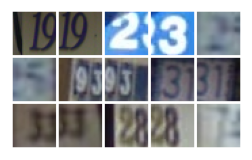

In [81]:
# Visualize training images

n_rows = 3 
n_cols = 5

_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize =(3, 3),
    n_rows=n_rows, 
    n_cols=n_cols,
)

###  Diffusion process

In [82]:
sigma = 25.0

def bm_drift_coefficient(x_t, t):
    return torch.zeros_like(x_t)

def bm_diffusion_coefficient(t, sigma=sigma):
    return sigma**t

def bm_mu_t(x_0, t):
    return x_0

def bm_sigma_t(t, sigma=sigma):
    return torch.sqrt(0.5 * (sigma**(2 * t) - 1.0) / np.log(sigma))

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient = bm_drift_coefficient,
    diffusion_coefficient = bm_diffusion_coefficient,
    mu_t = bm_mu_t,
    sigma_t = bm_sigma_t,
)

In [83]:
# Define the score model

from diffusion_lib import UNetScoreModelColor as ScoreNet

score_model = ScoreNet(marginal_prob_std=partial(bm_sigma_t, sigma=sigma))
score_model = score_model.to(device)

In [84]:
# # Train model

# from torch.optim import Adam
# import tqdm.notebook

# #  [TO DO: Comment each line of code]

# learning_rate = 1.0e-3
# optimizer = Adam(score_model.parameters(), lr=learning_rate)

# n_epochs = 500
# tqdm_epoch = tqdm.notebook.trange(n_epochs)

# for epoch in tqdm_epoch:
#     avg_loss = 0.0
#     num_items = 0
#     for x, y in data_loader:
#         x = x.to(device)    
#         loss = diffusion_process.loss_function(score_model, x)
#         optimizer.zero_grad()
#         loss.backward()    
#         optimizer.step()
#         avg_loss += loss.item() * x.shape[0]
#         num_items += x.shape[0]
        
#     tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))

#     torch.save(score_model.state_dict(), '../other_checkpoints/digit_6_{:d}_epochs.pth'.format(n_epochs))

In [85]:
from functools import partial
import torch

n_images = 5
n_epochs = 500

check_point = torch.load('../other_checkpoints/digit_6_{:d}_epochs.pth'.format(n_epochs), map_location='cpu')
score_model.load_state_dict(check_point)
score_model = score_model.cpu()

def backward_drift_coefficient(x_t, t, diffusion_coefficient):
    
    if not isinstance(t, torch.Tensor):
        t = torch.tensor([t], device='cpu', dtype=torch.float32)
    if t.dim() == 0 or t.shape[0] != x_t.shape[0]:
        t = t.expand(x_t.shape[0])
    
    score = score_model(x_t, t)
    view_shape = [x_t.shape[0]] + [1] * (x_t.dim() - 1)
    g_t = diffusion_coefficient(t).view(*view_shape)
    
    return -(g_t ** 2) * score

T = 1.0 
t_tensor = torch.tensor([T], device='cpu')
sigma_max = diffusion_process.sigma_t(t_tensor).detach().cpu()
image_T = torch.randn(n_images, 3, 32, 32, device='cpu') * sigma_max.view(1, 1, 1, 1)

with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        image_T,
        t_0 = T, 
        t_end = 1.0e-3,
        n_steps= 500,
        drift_coefficient=partial(
            backward_drift_coefficient,
            diffusion_coefficient=bm_diffusion_coefficient,
        ),
        diffusion_coefficient=bm_diffusion_coefficient, 
    )

score_model = score_model.to(device)

print(type(synthetic_images_t))
print(synthetic_images_t.shape)

<class 'torch.Tensor'>
torch.Size([5, 3, 32, 32, 501])


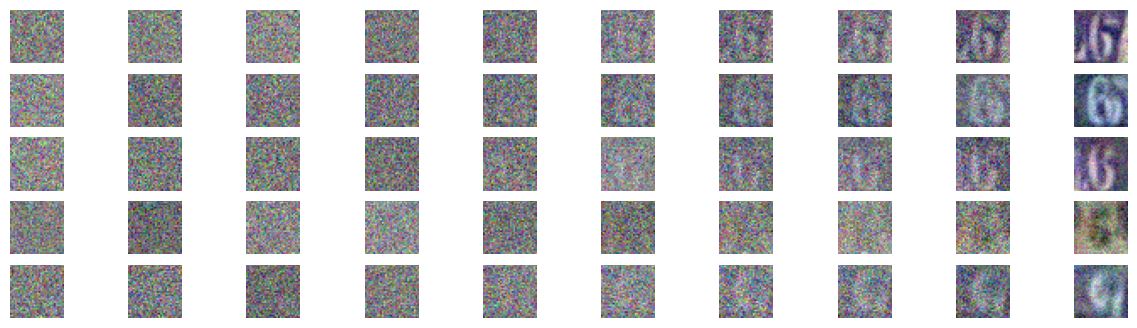

In [86]:
from diffusion_lib.utils.visualization import plot_image_evolution_rgb

_ = plot_image_evolution_rgb(
    
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)